# Red neuronal artificial para reconocer el tipo de un pokemon

En esta tarea ustedes deben diseñar, entrenar y evaluar un modelo de red neuronal con arquitectura convolucional para resolver el problema de reconocer el tipo de un pokemon en base a una imagen del mismo y a sus atributos. El principal desafio es el desbalance y poca cantidad de ejemplos en el dataset. 

A continuación se instancia el dataset y se itera para presentar algunos ejemplos:

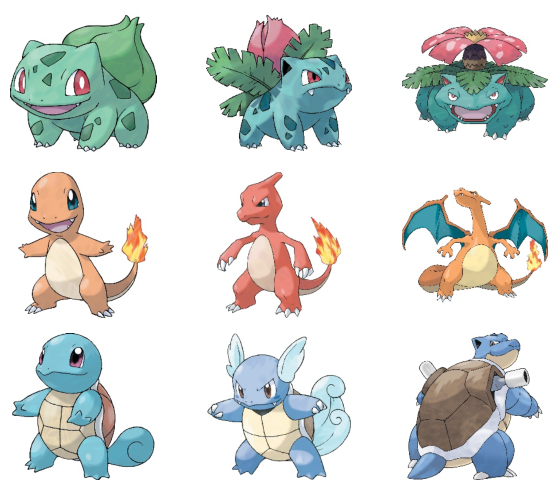

In [8]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import matplotlib.pyplot as plt
from pokemon_utils import PokemonImages

dataset = PokemonImages('data/')

fig, ax = plt.subplots(3, 3, figsize=(7, 5), tight_layout=True)
for ax_, (image, label, name, attributes) in zip(ax.ravel(), dataset):
    ax_.imshow(image.permute(-2, -1, 0))
    ax_.axis('off');

Cada ejemplo tiene su imagen, su etiqueta, su nombre y sus atributos:

In [9]:
image, label, name, attributes = dataset[3]
type(image), image.shape, label, name, attributes

(torch.Tensor,
 torch.Size([3, 256, 256]),
 np.int64(6),
 'Charmander',
 tensor([ 0.6000,  8.5000, 39.0000, 52.0000, 43.0000, 65.0000]))

Se puede obtener el nombre de la clase con:

In [10]:
dataset.categories[label]

'Fire'

Y los atributos disponibles son:

In [11]:
dataset.attribute_names

['Height', 'Weight', 'HP', 'Attack', 'Defense', 'Speed']

La cantidad de ejemplos por clase es:

In [12]:
from collections import Counter
import pandas as pd
x = Counter(dataset.labels)
for key in sorted(x):
    print(f"{dataset.categories[key]}: {x[key]}")

Bug: 52
Dark: 20
Dragon: 13
Electric: 32
Fairy: 8
Fighting: 20
Fire: 34
Ghost: 18
Grass: 58
Ground: 26
Ice: 19
Normal: 80
Poison: 26
Psychic: 44
Rock: 32
Steel: 17
Water: 96


En lo que sigue utilice los siguientes conjuntos de entrenamiento (train) y prueba (test). 

In [13]:
import numpy as np
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(len(dataset)),test_size=0.15, random_state=1234, 
                                       shuffle=True, stratify=dataset.labels)

train_dataset = Subset(dataset, train_idx)
test_dataset = Subset(dataset, test_idx)

### Definición del modelo

Defina e implemente un modelo apropiado para el problema. Justifique sus decisiones de diseño.

Antes de implementar el modelo para resolver el problema, tenemos que saber exactamente de qué tamaño son las imágenes (saber cuantos pixeles de alto y ancho tienen).

In [14]:
from pokemon_utils import PokemonImages

dataset_prueba = PokemonImages(data_path='data')

imagen_tensor, etiqueta, nombre, atributos = dataset_prueba[0]

print(f"Pokémon: {nombre}")
print(f"Dimensiones del tensor (Canales, Alto, Ancho): {imagen_tensor.shape}")

Pokémon: Bulbasaur
Dimensiones del tensor (Canales, Alto, Ancho): torch.Size([3, 256, 256])


Calcularemos el número para la variable *dimensiones_imagen_plana* de nuestro modelo:
- Los resultados arrojaron que tenemos un Alto x Ancho de 256 x 256
- Se aplicara una división por 4
- Finalmente se aplica la formula 32 * (Alto final) * (Ancho final)

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PokemonMultiModal(nn.Module):
    def __init__(self, num_atributos_numericos, num_clases):
        super().__init__()
        
        # =========================================
        # RAMA 1: Procesamiento de la Imagen (CNN)
        # =========================================
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Aplana la imagen para conectarla a la red densa
            nn.Flatten()
        )
        
        dimensiones_imagen_plana = 32 * 64 * 64 # 32 * Ancho_final * Alto_final (después de las capas convolucionales y pooling)
        
        # =========================================
        # RAMA 2: Procesamiento de los Atributos (MLP)
        # =========================================
        self.mlp = nn.Sequential(
            nn.Linear(num_atributos_numericos, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        
        # =========================================
        # CABEZA FINAL (Fusión de ambas ramas)
        # =========================================
        # Sumamos el tamaño de salida de la CNN y el tamaño de salida del MLP
        tamanio_concatenado = dimensiones_imagen_plana + 16
        
        self.clasificador_final = nn.Sequential(
            nn.Linear(tamanio_concatenado, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Para evitar el sobreajuste
            nn.Linear(64, num_clases)
        )

    def forward(self, imagen, atributos):
        # 1. Pasar la imagen por la CNN
        caracteristicas_visuales = self.cnn(imagen)
        
        # 2. Pasar los números por el MLP
        caracteristicas_numericas = self.mlp(atributos)
        
        # 3. Juntar ambas ramas (concatenar a lo largo de la dimensión 1)
        fusion = torch.cat((caracteristicas_visuales, caracteristicas_numericas), dim=1)
        
        # 4. Decisión final
        salida = self.clasificador_final(fusion)
        return salida

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader

# 1. Usamos los datasets oficiales 
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 2. Solución al Desbalance: Calcular pesos por clase
# Extraemos todas las etiquetas de entrenamiento para contar cuántas hay de cada tipo
etiquetas_train = [train_dataset[i][1] for i in range(len(train_dataset))]
conteo_clases = np.bincount(etiquetas_train, minlength=(len(dataset.categories)))
print("número de clases:", len(dataset.categories))

# Calculamos el peso (inversamente proporcional a la frecuencia)
# Le sumamos 1e-5 para evitar dividir por cero si alguna clase tiene 0 ejemplos
pesos_clases = len(etiquetas_train) / (len(dataset.categories) * (conteo_clases + 1e-5))
pesos_tensor = torch.tensor(pesos_clases, dtype=torch.float32)

# 3. Solución a las escalas: Calcular Media y Desviación para Normalizar
# Extraemos los atributos numéricos para saber su escala real
atributos_train = torch.stack([train_dataset[i][3] for i in range(len(train_dataset))])
atr_mean = atributos_train.mean(dim=0)
atr_std = atributos_train.std(dim=0)

print("DataLoaders listos con el split oficial.")
print("Pesos para la pérdida calculados (para combatir el desbalance).")
print("Estadísticas de normalización calculadas.")

nuemro de clases: 18
DataLoaders listos con el split oficial.
Pesos para la pérdida calculados (para combatir el desbalance).
Estadísticas de normalización calculadas.


### Entrenamiento del modelo

Entrene el modelo y muestre las curvas de aprendizaje. Justifique la elección de hiperparámetros.

**Elección y justificación de Hiperparámetros y Diseño de Entrenamiento:**

* **Función de Pérdida (`CrossEntropyLoss` con pesos):** Al ser un problema de clasificación multiclase (18 tipos elementales), esta es la función matemática estándar. Sin embargo, para atacar el principal desafío de la tarea (el desbalance de clases), calculamos la frecuencia inversa de cada tipo de Pokémon en el set de entrenamiento y se lo pasamos como parámetro `weight`. Esto hace que la red reciba una penalización mucho mayor si se equivoca en una clase minoritaria (ej. Hielo) que en una mayoritaria (ej. Agua).
* **Normalización Tabular (Prevención de Data Leakage):** Los 6 atributos numéricos tienen escalas muy distintas (ej. Stats de 200 vs Alturas de 1.5m). Para estabilizar el aprendizaje de la rama MLP, estandarizamos estos datos restando la media y dividiendo por la desviación estándar. Es vital destacar que estos valores estadísticos se calcularon **exclusivamente con el set de entrenamiento**, y esos mismos valores se aplicaron al set de prueba para evitar "fuga de datos" (que el modelo adquiera información del set de evaluación antes de tiempo).
* **Optimizador (`Adam`, lr=0.001):** Ideal para arquitecturas multimodales porque adapta dinámicamente la tasa de aprendizaje para cada peso de la red, evitando estancamientos. El *Learning Rate* de 0.001 es un inicio conservador y estable.


In [ ]:
import torch.optim as optim
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_final = PokemonMultiModal(num_atributos_numericos=6, num_clases=len(dataset.categories)).to(device)

# --- CORRECCIÓN: Le pasamos los pesos calculados a la función de pérdida ---
pesos_tensor = pesos_tensor.to(device)
criterio = nn.CrossEntropyLoss(weight=pesos_tensor)
optimizador = optim.Adam(modelo_final.parameters(), lr=0.001)
epocas = 30

loss_historial = []
atr_mean = atr_mean.to(device)
atr_std = atr_std.to(device)

print(f"Iniciando entrenamiento BASE por {epocas} épocas...")

for epoca in range(epocas):
    modelo_final.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas, nombres, atributos in train_loader:
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)
        atributos = atributos.to(device)
        
        # --- CORRECCIÓN: Normalizamos los atributos numéricos ---
        # Restamos la media y dividimos por la desviación estándar
        atributos_normalizados = (atributos - atr_mean) / (atr_std + 1e-7)
        
        optimizador.zero_grad()
        
        # Usamos los atributos normalizados
        predicciones = modelo_final(imagenes, atributos_normalizados)
        loss = criterio(predicciones, etiquetas)
        
        loss.backward()
        optimizador.step()
        
        loss_acumulada += loss.item()
        
    loss_promedio = loss_acumulada / len(train_loader)
    loss_historial.append(loss_promedio)
    
    if (epoca + 1) % 5 == 0:
        print(f"Época [{epoca+1}/{epocas}] | Loss: {loss_promedio:.4f}")
        
print("¡Entrenamiento finalizado!")

Iniciando entrenamiento BASE por 30 épocas...
Época [5/30] | Loss: 2.7270
Época [10/30] | Loss: 1.7552
Época [15/30] | Loss: 1.2848
Época [20/30] | Loss: 1.0987
Época [25/30] | Loss: 0.9793
Época [30/30] | Loss: 0.8262
¡Entrenamiento finalizado!


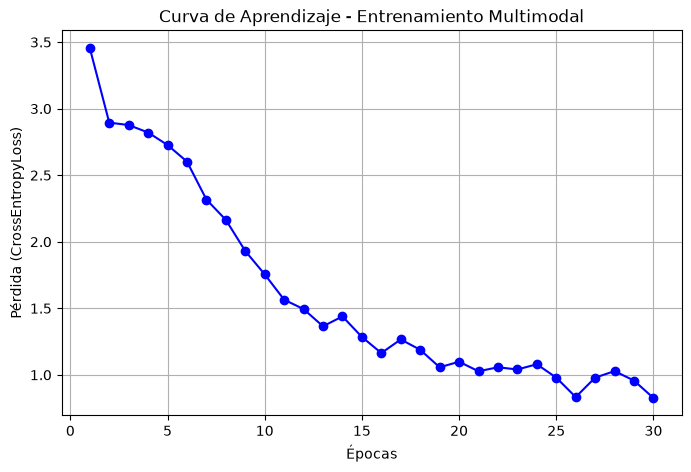

In [19]:
import matplotlib.pyplot as plt

# Generar la Curva de Aprendizaje
plt.figure(figsize=(8, 5))
plt.plot(range(1, epocas + 1), loss_historial, marker='o', linestyle='-', color='b')
plt.title("Curva de Aprendizaje - Entrenamiento Multimodal")
plt.xlabel("Épocas")
plt.ylabel("Pérdida (CrossEntropyLoss)")
plt.grid(True)
plt.show()

### Evaluación del modelo

Evalúe el modelo en el conjunto de prueba usando matriz de confusión y reporte de clasificación. Discuta los resultados.

### Análisis de errores

Analice algunos ejemplos mal clasificados y comente lo que observa.

### Aumentación de datos

Implemente un esquema de aumentación aleatoria de datos y compare los resultados con y sin aumentación.